###Boosting Techniques

## **Question 1: What is Boosting in Machine Learning? Explain how it improves weak learners.**

### **1. What is Boosting?**
**Boosting** is a powerful ensemble learning technique in machine learning that combines a sequence of weak classifiers (or regressors) to create a single, highly accurate strong classifier.

Unlike **Bagging** (like Random Forest), where models are trained in parallel and independently, Boosting trains models **sequentially**. Each new model in the sequence is specifically designed to correct the errors made by its predecessors.



### **2. How Boosting Improves Weak Learners**
A **weak learner** is a model that performs only slightly better than random guessing (for example, a shallow decision tree with only one split, known as a **decision stump**).

Boosting transforms these weak learners into a strong ensemble through the following step-by-step mechanism:

* **Initial Training:** The algorithm starts by training a base weak learner on the entire dataset, where all data points are assigned equal weight ($w_i = \frac{1}{N}$).
* **Error Evaluation:** The algorithm identifies which data points the weak learner misclassified or predicted poorly.
* **Weight Adjustment (The Core Mechanism):** * The weights of the **misclassified data points are increased**.
  * The weights of the **correctly classified data points are decreased**.
* **Sequential Learning:** The next weak learner is trained on this updated dataset. Because of the adjusted weights, this new model is forced to focus more heavily on the "hard" examples that the previous model got wrong.
* **Final Combination:** This process repeats for a predetermined number of iterations. Finally, all the weak learners are combined into a single model using a weighted majority vote (for classification) or a weighted sum (for regression). Models that performed better individually are given higher voting power in the final ensemble.



## **Question 2: What is the difference between AdaBoost and Gradient Boosting in terms of how models are trained?**

While both AdaBoost and Gradient Boosting are sequential ensemble methods, they differ fundamentally in **what** they change and **how** they optimize the model at each step.


| Feature | AdaBoost (Adaptive Boosting) | Gradient Boosting |
| :--- | :--- | :--- |
| **Core Strategy** | Corrects mistakes by **adjusting data weights**. | Corrects mistakes by **predicting residual errors**. |
| **How it works** | High weights are assigned to data points that were misclassified by the previous tree. The next tree is forced to focus on these hard-to-classify points. | Instead of changing data weights, the next tree is trained directly on the *residuals* (the differences between actual and predicted values) of the previous tree. |
| **Tree Structure** | Typically uses **Decision Stumps** (trees with a depth of 1, having only 1 split and 2 terminal leaves). | Uses larger but still relatively shallow trees (typically with a depth of 3 to 6). |
| **Optimization Method** | Optimizes an **Exponential Loss Function** by giving a higher voice/weight to models with lower overall error rates. | Optimizes arbitrary differentiable loss functions (like Mean Squared Error or Log Loss) using **Gradient Descent**. |
| **Final Prediction** | A weighted majority vote or sum where more accurate trees have a higher say in the final output. | Sum of predictions from all trees multiplied by a learning rate ($\alpha$). |


### Question 3: How does regularization help in XGBoost?

**Answer:**

Regularization is a technique used in XGBoost to **prevent overfitting** and improve the model's ability to generalize to new, unseen data. Since XGBoost builds many decision trees sequentially, the model can become too complex and start learning noise from the training data. Regularization controls this complexity by adding a penalty to the model during training.

XGBoost uses two types of regularization:

1. **L1 Regularization (Lasso):**
   - Adds a penalty based on the absolute values of the leaf weights.
   - Reduces the importance of less useful features by shrinking some weights to zero.
   - Helps in feature selection and creates a simpler model.

2. **L2 Regularization (Ridge):**
   - Adds a penalty based on the squared values of the leaf weights.
   - Prevents the leaf weights from becoming too large.
   - Produces a more stable and robust model.

By using regularization, XGBoost:
- Reduces overfitting.
- Controls the complexity of decision trees.
- Improves generalization on unseen data.
- Produces a more stable and accurate model.

### Question 4: Why is CatBoost considered efficient for handling categorical data?

**Answer:**

CatBoost is considered highly efficient for handling categorical data because it can **process categorical features directly without requiring manual encoding** such as One-Hot Encoding or Label Encoding. This makes data preprocessing simpler and reduces the risk of losing important information.

CatBoost uses a technique called **Ordered Target Encoding**, which converts categorical values into numerical values based on the target variable while preventing target leakage. This allows the model to learn meaningful patterns from categorical features without introducing bias.

The main reasons CatBoost is efficient for categorical data are:

- It **automatically handles categorical features**, eliminating the need for manual encoding.
- It uses **Ordered Target Encoding**, which reduces overfitting and prevents data leakage.
- It captures complex relationships between categorical variables more effectively than traditional encoding methods.
- It requires less preprocessing, making model development faster and easier.
- It often achieves higher accuracy on datasets containing many categorical features.

Because of these advantages, CatBoost is widely used for real-world datasets that contain a large number of categorical variables.

### Question 5: What are some real-world applications where boosting techniques are preferred over bagging methods?

**Answer:**

Boosting techniques are preferred over bagging methods when **high prediction accuracy** is more important than training speed. Since Boosting learns from the mistakes of previous models, it performs well on complex datasets where capturing subtle patterns is important.

Some common real-world applications include:

1. **Fraud Detection:** Identifying fraudulent banking or online transactions by learning complex fraud patterns.

2. **Credit Risk Assessment:** Predicting whether a loan applicant is likely to repay a loan based on financial and personal information.

3. **Medical Diagnosis:** Detecting diseases such as cancer, diabetes, or heart disease from patient records and medical test results.

4. **Customer Churn Prediction:** Identifying customers who are likely to stop using a product or service so that companies can take preventive actions.

5. **Search Engine Ranking:** Ranking web pages based on their relevance to a user's search query.

6. **Recommendation Systems:** Recommending products, movies, or songs by learning user preferences and behavior.

7. **Sales and Demand Forecasting:** Predicting future sales or product demand to improve inventory and business planning.

Boosting methods are preferred in these applications because they usually provide **higher accuracy**, **better handling of complex relationships**, and **improved performance** compared to bagging methods.

### Question 6: Write a Python program to:
#### -  Train an AdaBoost Classifier on the Breast Cancer dataset
#### - Print the model accuracy
###**Answer:**

In [1]:
# Import required libraries
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score

# Load the Breast Cancer dataset
data = load_breast_cancer()

# Features and Target
X = data.data
y = data.target

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Create the AdaBoost Classifier
model = AdaBoostClassifier(
    n_estimators=50,
    random_state=42
)

# Train the model
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)

# Print the result
print("Model Accuracy:", round(accuracy * 100, 2), "%")

Model Accuracy: 96.49 %


### Question 7: Write a Python program to:
#### -  Train a Gradient Boosting Regressor on the California Housing dataset
#### -  Evaluate performance using R-squared score

###**Answer:**

In [2]:
# Import required libraries
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score

# Load the California Housing dataset
housing = fetch_california_housing()

# Features and Target
X = housing.data
y = housing.target

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Create the Gradient Boosting Regressor
model = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)

# Train the model
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Calculate R-squared Score
r2 = r2_score(y_test, y_pred)

# Print the result
print("R-squared Score:", round(r2, 4))

R-squared Score: 0.7756


### Question 8: Write a Python program to:
#### -  Train an XGBoost Classifier on the Breast Cancer dataset
#### -  Tune the learning rate using GridSearchCV
#### - Print the best parameters and accuracy
###**Answer:**

In [3]:
!pip install xgboost -q

In [4]:
# Import required libraries
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score
from xgboost import XGBClassifier

# Load the Breast Cancer dataset
data = load_breast_cancer()

# Features and Target
X = data.data
y = data.target

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Create the XGBoost Classifier
model = XGBClassifier(
    n_estimators=100,
    eval_metric="logloss",
    random_state=42
)

# Define parameter grid
param_grid = {
    "learning_rate": [0.01, 0.05, 0.1, 0.2, 0.3]
}

# Apply GridSearchCV
grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

# Train the model
grid_search.fit(X_train, y_train)

# Best model
best_model = grid_search.best_estimator_

# Make predictions
y_pred = best_model.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)

# Print results
print("Best Parameters:", grid_search.best_params_)
print("Model Accuracy:", round(accuracy * 100, 2), "%")

Best Parameters: {'learning_rate': 0.2}
Model Accuracy: 95.61 %


###Question 9: Write a Python program to:
#### - Train a CatBoost Classifier
#### -  Plot the confusion matrix using seaborn
###**Answer:**

In [5]:
!pip install catboost -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.1 MB/s eta 0:00:00


Model Accuracy: 96.49 %


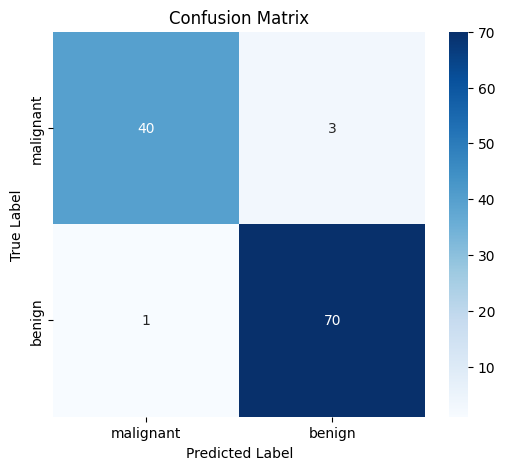

In [6]:
# Import required libraries
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score
from catboost import CatBoostClassifier

# Load the Breast Cancer dataset
data = load_breast_cancer()

# Features and Target
X = data.data
y = data.target

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Create the CatBoost Classifier
model = CatBoostClassifier(
    iterations=100,
    learning_rate=0.1,
    depth=6,
    random_state=42,
    verbose=0
)

# Train the model
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", round(accuracy * 100, 2), "%")

# Create Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# Plot Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=data.target_names,
    yticklabels=data.target_names
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

###Question 10: You're working for a FinTech company trying to predict loan default using customer demographics and transaction behavior.The dataset is imbalanced, contains missing values, and has both numeric and categorical features. Describe your step-by-step data science pipeline using boosting techniques:
#### -  Data preprocessing & handling missing/categorical values
#### -  Choice between AdaBoost, XGBoost, or CatBoost
#### -  Hyperparameter tuning strategy
#### -  Evaluation metrics you'd choose and why
#### -  How the business would benefit from your model
###**Answer:**

 - Step 1: Data Preprocessing
    - Handle missing values by filling numerical columns with the median and categorical columns with the most frequent value.
    - Encode categorical variables. If using CatBoost, categorical features can be used directly without manual encoding.
    - Split the dataset into training and testing sets.
    - Since the dataset is imbalanced, use techniques such as class weights or oversampling (e.g., SMOTE) to balance the classes.
 - Step 2: Choosing the Boosting Algorithm
    - AdaBoost: Suitable for simple datasets but less effective on large or complex datasets.
    - XGBoost: Excellent for structured/tabular data, handles missing values efficiently, offers regularization, and provides high accuracy.
    - CatBoost: Best choice when the dataset contains many categorical features because it handles them automatically and reduces preprocessing.
 - Step 3: Hyperparameter Tuning

    - Use GridSearchCV or RandomizedSearchCV to tune parameters such as:

        - iterations
        - learning_rate
        - depth
        - l2_leaf_reg

    - The best combination is selected using cross-validation.
 - Step 4: Evaluation Metrics

    - Since the dataset is imbalanced, accuracy alone is not sufficient.

    - The preferred evaluation metrics are:

        - Precision
        - Recall
        - F1-Score
        - ROC-AUC Score
        - Confusion Matrix

    - These metrics provide a better understanding of how well the model identifies loan defaulters.

 - Step 5: Business Benefits

    - The model helps the company to:

        - Identify high-risk customers before approving loans.
        - Reduce financial losses caused by loan defaults.
        - Improve the loan approval process.
        - Make faster and more accurate lending decisions.
        - Increase profitability while reducing credit risk.

In [7]:
# Import required libraries
import pandas as pd

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, roc_auc_score
from catboost import CatBoostClassifier

# Load sample dataset
data = load_breast_cancer(as_frame=True)

df = data.frame

X = df.drop("target", axis=1)
y = df["target"]

# Handle missing values
imputer = SimpleImputer(strategy="median")
X = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Create CatBoost model
model = CatBoostClassifier(
    verbose=0,
    random_state=42
)

# Hyperparameter Grid
param_grid = {
    "iterations": [100, 200],
    "learning_rate": [0.05, 0.1],
    "depth": [4, 6]
}

# Grid Search
grid = GridSearchCV(
    model,
    param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

# Train model
grid.fit(X_train, y_train)

# Best model
best_model = grid.best_estimator_

# Predictions
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

# Print results
print("Best Parameters:", grid.best_params_)
print("ROC-AUC Score:", round(roc_auc_score(y_test, y_prob), 4))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Best Parameters: {'depth': 4, 'iterations': 200, 'learning_rate': 0.1}
ROC-AUC Score: 0.9937

Classification Report:

              precision    recall  f1-score   support

           0       0.95      0.90      0.93        42
           1       0.95      0.97      0.96        72

    accuracy                           0.95       114
   macro avg       0.95      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114

